# National Income forecasting

In this notebook, we try to extrapolate the national income per capita based on historic annual data from the 1970s to get data for years 2020-2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

In [2]:
# --- Configuration ---
DATA_PATH = '~/gcs-buckets/National_Income_per_capita_till_2023/'
FILE_PATH = os.path.join(DATA_PATH, 'national_income_per_capita_2023.csv')
FORECAST_HORIZON = 6 # years
TARGET_COLUMN = 'Income_Per_Capita' # Adjust if your column name is different
DATE_COLUMN = 'Year' # Adjust if your column name is different (e.g., 'Date')

## 1. Data Loading and EDA

In [3]:
# --- 1. Load Data ---
df = pd.read_csv(FILE_PATH)
columns = ["country"] + [str(1970 + i) for i in range(52)]
df = df[columns]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 53 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  266 non-null    object 
 1   1970     73 non-null     float64
 2   1971     107 non-null    float64
 3   1972     107 non-null    float64
 4   1973     109 non-null    float64
 5   1974     109 non-null    float64
 6   1975     109 non-null    float64
 7   1976     112 non-null    float64
 8   1977     112 non-null    float64
 9   1978     112 non-null    float64
 10  1979     111 non-null    float64
 11  1980     153 non-null    float64
 12  1981     158 non-null    float64
 13  1982     158 non-null    float64
 14  1983     158 non-null    float64
 15  1984     160 non-null    float64
 16  1985     163 non-null    float64
 17  1986     166 non-null    float64
 18  1987     167 non-null    float64
 19  1988     168 non-null    float64
 20  1989     173 non-null    float64
 21  1990     178 non

In [4]:
df["2022"], df["2023"], df["2024"], df["2025"] = np.nan, np.nan, np.nan, np.nan

In [5]:
df["num_timesteps"] = 0

for i, row in df.iterrows():
    df.at[i, "num_timesteps"] = row[1:].count()

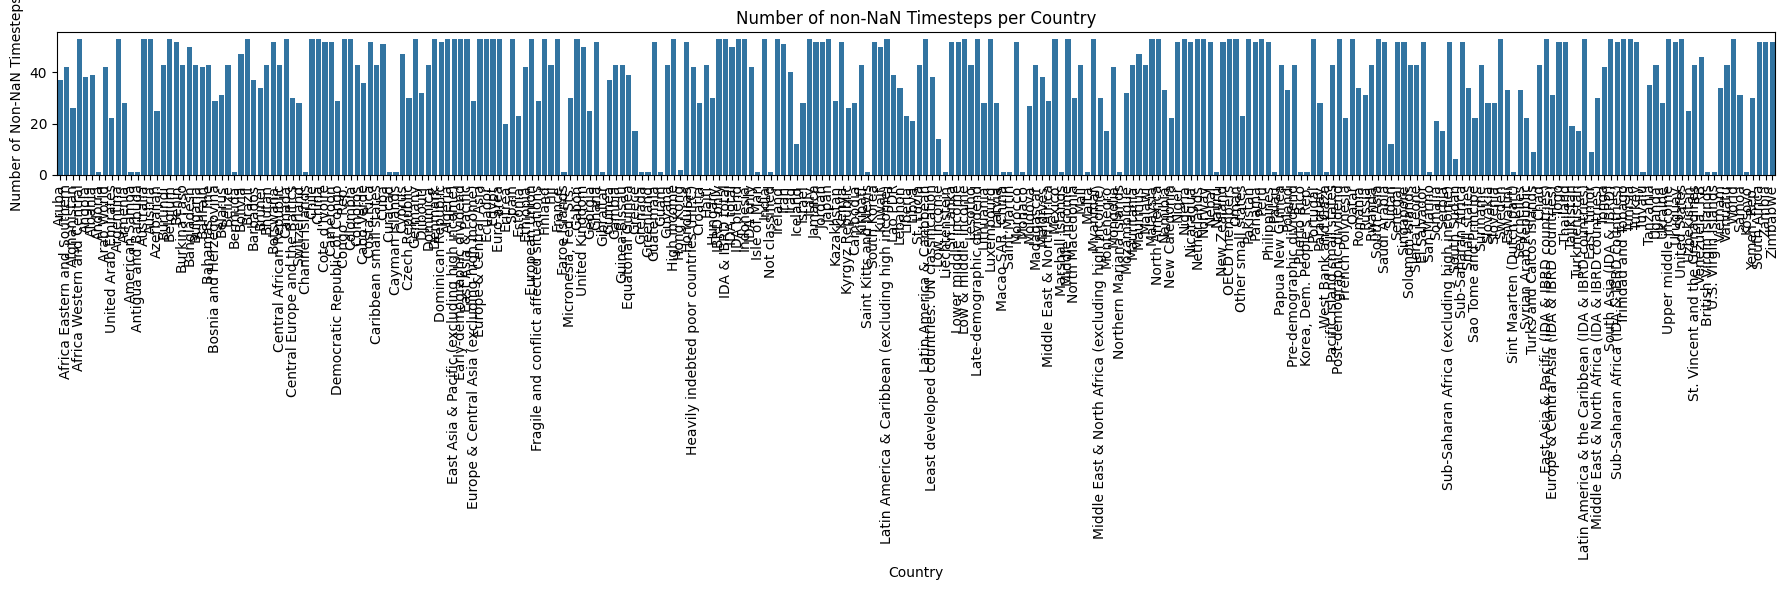

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
plt.title("Number of non-NaN Timesteps per Country")
sns.barplot(x=df["country"], y=df["num_timesteps"])
# plt.plot(df["num_timesteps"])
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Number of Non-NaN Timesteps")
plt.tight_layout()
plt.show()

Let's first try for a single nation, then replicate this to other nations.

In [7]:
country = "United Kingdom"
df1 = df[df["country"] == country].drop(columns=["country","num_timesteps"]).T.reset_index()
df1.rename(columns={df1.columns[0]: DATE_COLUMN, df1.columns[1]: TARGET_COLUMN}, inplace=True)
df1

,Year,Income_Per_Capita
0,1970,2267.450040
1,1971,2534.270487
2,1972,2881.707738
3,1973,3246.470747
4,1974,3456.507280
5,1975,4064.554993
6,1976,3891.152906
7,1977,4308.658951
8,1978,5473.196929
9,1979,6967.861662


In [8]:
# Convert the date column to datetime objects and set as index
# Assuming 'Year' is an integer, convert it to a string for parsing 'YYYY-01-01'
df1[DATE_COLUMN] = pd.to_datetime(df1[DATE_COLUMN].astype(str) + '-01-01')
df1.set_index(DATE_COLUMN, inplace=True)
df1 = df1.sort_index()

# Ensure the frequency is set for time series operations (Year Start)
df1 = df1.asfreq('YS')

print("Data Head:")
df1.head()

Data Head:


,Income_Per_Capita
Year,
1970-01-01,2267.450040
1971-01-01,2534.270487
1972-01-01,2881.707738
1973-01-01,3246.470747
1974-01-01,3456.507280


In [9]:
print("Data Info:")
df1.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 56 entries, 1970-01-01 to 2025-01-01
Freq: YS-JAN
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Income_Per_Capita  49 non-null     float64
dtypes: float64(1)
memory usage: 896.0 bytes


In [10]:
print("Data Description:")
df1.describe()

Data Description:


,Income_Per_Capita
count,49.000000
mean,20080.320370
std,13042.661217
min,2267.450040
25%,7601.090534
50%,17960.752838
75%,34106.744384
max,42710.970880


In [11]:
# Check for missing values
print("Missing values per column:")
print(df1.isnull().sum())
# Handle missing values if any (e.g., df.fillna(method='ffill', inplace=True))
# For annual income, it's less likely to have internal missing values, but good to check.

Missing values per column:
Income_Per_Capita    7
dtype: int64


--- Performing EDA ---


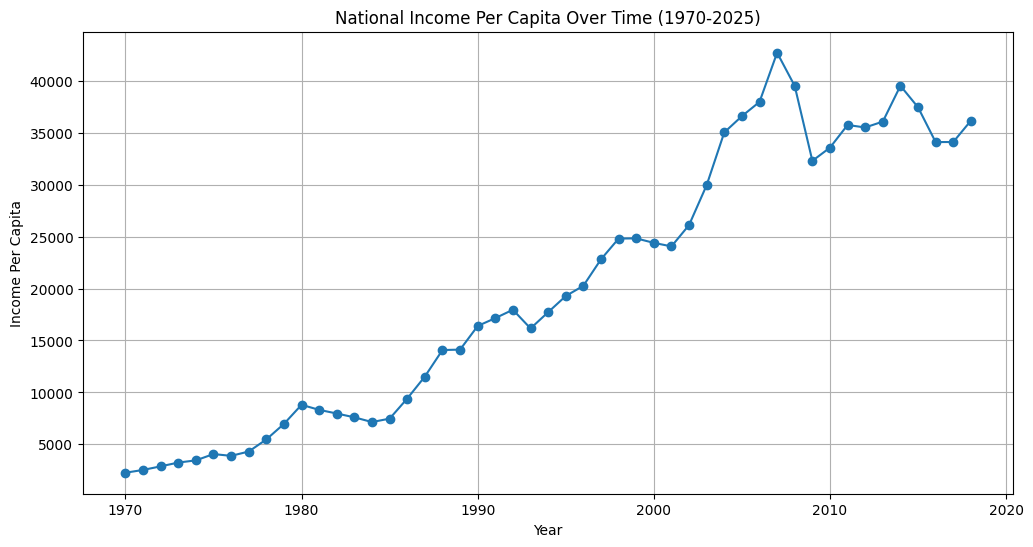

In [12]:
# --- 2. Exploratory Data Analysis (EDA) ---
print("--- Performing EDA ---")

# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(df1.index, df1[TARGET_COLUMN], marker='o')
plt.title(f'National Income Per Capita Over Time ({df1.index.min().year}-{df1.index.max().year})')
plt.xlabel('Year')
plt.ylabel('Income Per Capita')
plt.grid(True)
plt.savefig('income_time_series.png') # Save plot to VM
plt.show() # Will only show if you run locally or use a display server

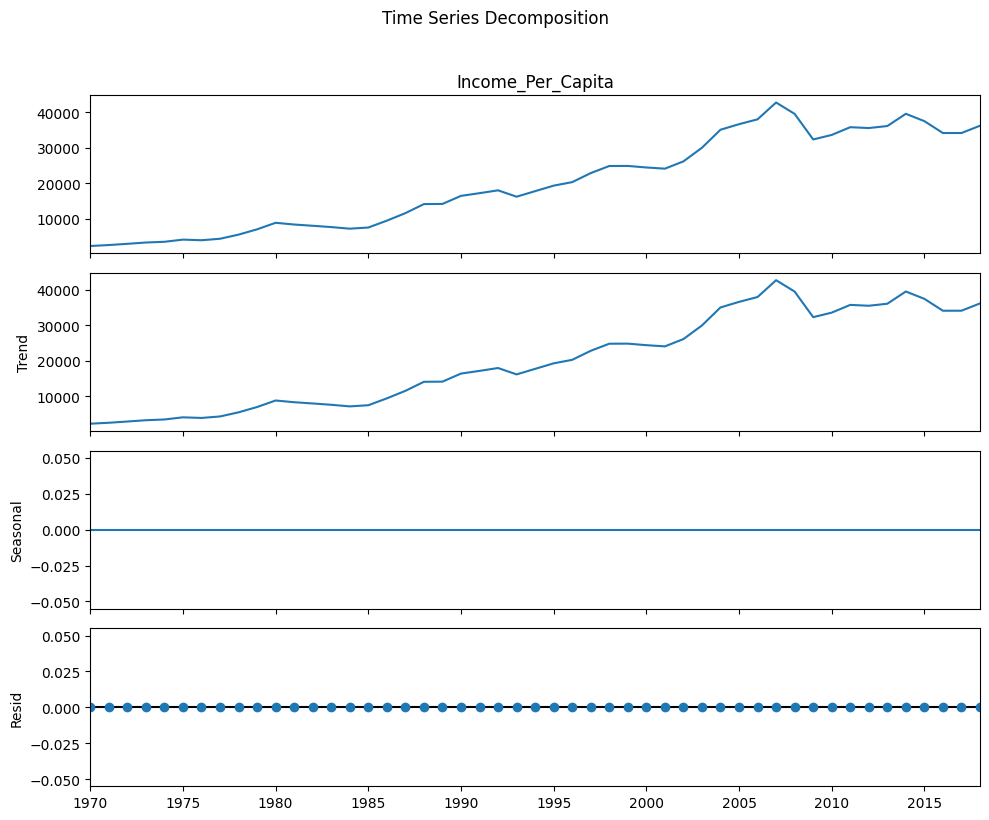

In [13]:
# Time Series Decomposition (Trend, Seasonality, Residuals)
# For annual data, seasonality might not be meaningful or will be represented as a cycle.
# period=1 is often used for annual data to signify no real repeating seasonality within the year.
# However, if there are long term cycles (e.g., business cycles), decompose can show them as trends.
try:
    decomposition = seasonal_decompose(df1[~df1[TARGET_COLUMN].isnull()][TARGET_COLUMN], model='additive', period=1) # period=1 for annual non-seasonal
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle('Time Series Decomposition', y=1.02)
    plt.tight_layout()
    plt.savefig('time_series_decomposition.png')
    plt.show()
except Exception as e:
    print(f"Could not perform decomposition (e.g., not enough data points for period): {e}")

In [14]:
# Stationarity Check (Augmented Dickey-Fuller Test)
print("--- ADF Test for Stationarity ---")
result = adfuller(df1[~df1[TARGET_COLUMN].isnull()][TARGET_COLUMN])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] > 0.05:
    print("Series is likely non-stationary. Consider differencing.")
else:
    print("Series is likely stationary.")

# If non-stationary, apply differencing and re-check (e.g., df[TARGET_COLUMN].diff().dropna())
# For auto_arima, it will handle differencing automatically.

--- ADF Test for Stationarity ---
ADF Statistic: -0.5917904328111152
p-value: 0.8728262831679074
Critical Values:
	1%: -3.5925042342183704
	5%: -2.931549768951162
	10%: -2.60406594375338
Series is likely non-stationary. Consider differencing.


In [15]:
# --- 3. Train-Test Split ---
print("--- Performing Train-Test Split ---")
# Split data into training and testing sets
# Test set will be the last `FORECAST_HORIZON` years (2014-2019)
train_data = df1[~df1["Income_Per_Capita"].isnull()].iloc[:-FORECAST_HORIZON] # Data from 1970 to 2013
test_data = df1[~df1["Income_Per_Capita"].isnull()].iloc[-FORECAST_HORIZON:]  # Data from 2014 to 2019

print(f"Train data from {train_data.index.min().year} to {train_data.index.max().year}")
print(f"Test data from {test_data.index.min().year} to {test_data.index.max().year}")


--- Performing Train-Test Split ---
Train data from 1970 to 2012
Test data from 2013 to 2018


## 2. Model training and comparison

Here, we try to fit the Prophet model to get the forecast and then a foundational model - TimesFM to get a forecast.

In [16]:
# --- 4. Model Training ---

# Model 1: Facebook Prophet
print("\n--- Training Prophet Model ---")
# Prophet requires specific column names: 'ds' for date and 'y' for value.
prophet_df_train = train_data.reset_index()
prophet_df_train.rename(columns={DATE_COLUMN: 'ds', TARGET_COLUMN: 'y'}, inplace=True)

prophet_model = Prophet(
    growth='linear', # or 'logistic' if you know there's a saturation point
    seasonality_mode='additive', # or 'multiplicative'
    yearly_seasonality=False, # No yearly seasonality for purely annual data
    weekly_seasonality=False,
    daily_seasonality=False
)
# Add custom yearly seasonality if you expect some cyclic behaviour but not strict 'seasonal'
# prophet_model.add_seasonality(name='annual_cycle', period=1, fourier_order=5) # Example for annual cycle
prophet_model.fit(prophet_df_train)

print("Prophet Model fitted.")

01:29:49 - cmdstanpy - INFO - Chain [1] start processing



--- Training Prophet Model ---


01:29:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model fitted.



--- Evaluating Prophet Model ---
Prophet MAE: 5781.77
Prophet RMSE: 6575.21


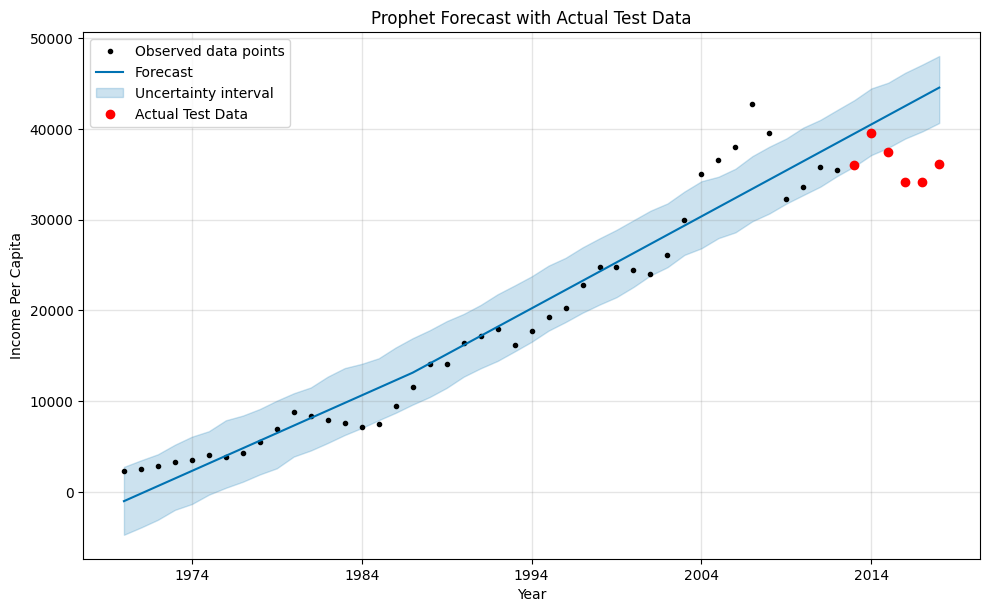

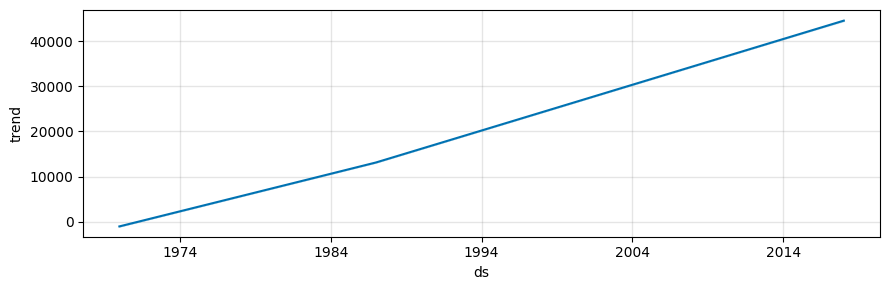

In [17]:
# --- 5. Evaluation ---

# Forecast with Prophet
print("\n--- Evaluating Prophet Model ---")
# Create future dataframe for Prophet predictions
future = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='YS')
prophet_forecast = prophet_model.predict(future)

# Filter Prophet forecast to just the test period
prophet_forecast_test = prophet_forecast[prophet_forecast['ds'].isin(test_data.index)]
prophet_forecast_test_values = prophet_forecast_test['yhat']

# Evaluate Prophet
prophet_mae = mean_absolute_error(test_data[TARGET_COLUMN], prophet_forecast_test_values)
prophet_rmse = np.sqrt(mean_squared_error(test_data[TARGET_COLUMN], prophet_forecast_test_values))
print(f'Prophet MAE: {prophet_mae:.2f}')
print(f'Prophet RMSE: {prophet_rmse:.2f}')

# Plot Prophet forecast vs actual
fig_prophet = prophet_model.plot(prophet_forecast)
ax = fig_prophet.gca()
ax.plot(test_data.index, test_data[TARGET_COLUMN], 'ro', label='Actual Test Data') # Plot actual test points
ax.set_title('Prophet Forecast with Actual Test Data')
ax.set_xlabel('Year')
ax.set_ylabel('Income Per Capita')
plt.legend()
plt.savefig('prophet_forecast_vs_actual.png')
plt.show()
prophet_model.plot_components(prophet_forecast).savefig('prophet_components.png')

In [18]:
from neuralforecast.models import PatchTST
from neuralforecast import NeuralForecast

Now, let's write a script to train PatchTST for each country

In [19]:
def neural_ts_forecasting(df, kwargs=None):
    """
    Function to perform time series forecasting using PatchTST model.
    
    Parameters:
    - df: DataFrame with columns ['ds', 'y', 'unique_id']
    
    Returns:
    - forecast_df: DataFrame with forecasted values
    """
    # Get the parameters
    input_size = kwargs.get('input_size', 4)  # Number of past observations to consider
    horizon = kwargs.get('horizon', 6)  # Number of steps to forecast
    max_steps = kwargs.get('max_steps', 100)  # Maximum steps for the model to forecast
    freq = kwargs.get('freq', 'D')  # Frequency of the time series, e.g., 'D' for daily, 'M' for monthly
    patch_len = kwargs.get('patch_len', 16)  # Length of the patch for PatchTST
    early_stop_steps = kwargs.get('early_stop_steps', 5)  # Early stopping steps
    
    # Define model
    model = PatchTST(h=horizon, input_size=input_size, max_steps=max_steps,
                     patch_len=patch_len, early_stop_patience_steps=early_stop_steps)
    
    # Run forecast
    nf = NeuralForecast(models=[model], freq=freq, local_scaler_type='standard')
    nf.fit(df[:-horizon+5], val_size=horizon+1)  # Fit only the last n-horizon points to avoid future leakage
    forecast_df = nf.predict()

    # Metrics calculation
    mae = mean_absolute_error(df['y'][-horizon:], forecast_df['PatchTST'].values[-horizon:])
    rmse = np.sqrt(mean_squared_error(df['y'][-horizon:], forecast_df['PatchTST'].values[-horizon:]))
    
    return nf, forecast_df, {"mae": mae, "rmse": rmse}

In [20]:
def plot_ts_forecast(df, forecast_df, horizon):
    """
    Function to plot the actual time series and the forecasted values.
    
    Parameters:
    - df: DataFrame with actual time series data
    - forecast_df: DataFrame with forecasted values
    - horizon: Number of steps in the forecast
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df['ds'], df['y'], label='Actual Series', color='blue')
    plt.plot(forecast_df['ds'], forecast_df['PatchTST'], label='PatchTST Forecast', color='orange')
    plt.axvline(x=df['ds'].iloc[-horizon], color='red', linestyle='--', label='Forecast Start')
    plt.title('PatchTST Forecast vs Actual Series')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [21]:
# uk_forecast_df, uk_metrics = neural_ts_forecasting(, freq='Y', horizon=FORECAST_HORIZON, input_size=16, max_steps=100)
uk_df = df1.reset_index()
uk_df.rename(columns={DATE_COLUMN: 'ds', TARGET_COLUMN: 'y'}, inplace=True)
uk_df['unique_id'] = country  # Add unique_id for consistency with PatchTST input
uk_df.head()

,ds,y,unique_id
0,1970-01-01,2267.450040,United Kingdom
1,1971-01-01,2534.270487,United Kingdom
2,1972-01-01,2881.707738,United Kingdom
3,1973-01-01,3246.470747,United Kingdom
4,1974-01-01,3456.507280,United Kingdom


In [22]:
args = {
    "horizon": 10,
    "input_size": 4,
    "max_steps": 150,
    "freq": 'Y',  # Annual frequency for UK data
    "patch_len": 16  # Length of the patch for PatchTST
}
model, uk_forecast_df, uk_metrics = neural_ts_forecasting(uk_df[~uk_df["y"].isnull()], kwargs=args)
uk_metrics

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 400 K  | train
-----------------------------------------------------------
400 K     Trainable params
3         Non-trainable params
400 K     Total params
1.602     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
/home/asudarshan14/EpiCoV_Summer25/ts_forecast/lib/python3.11/site-packages/utilsforecast/processing.py:384: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/home/asudarshan14/EpiCoV_Summer25/ts_forecast/lib/python3.11/site-packages/utilsforecast/processing.py:440: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

{'mae': 1588.6746173297797, 'rmse': 2045.5165482578302}

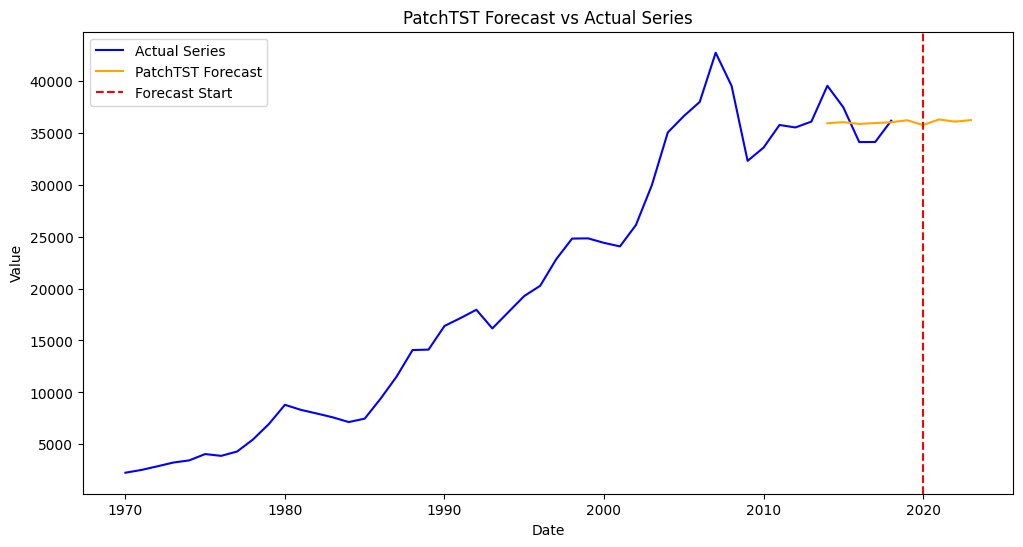

In [23]:
plot_ts_forecast(uk_df, uk_forecast_df, FORECAST_HORIZON)

In [24]:
model.predict()

/home/asudarshan14/EpiCoV_Summer25/ts_forecast/lib/python3.11/site-packages/utilsforecast/processing.py:384: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/home/asudarshan14/EpiCoV_Summer25/ts_forecast/lib/python3.11/site-packages/utilsforecast/processing.py:440: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,PatchTST
0,United Kingdom,2013-12-31,35917.546875
1,United Kingdom,2014-12-31,36024.125000
2,United Kingdom,2015-12-31,35850.710938
3,United Kingdom,2016-12-31,35939.148438
4,United Kingdom,2017-12-31,36011.734375
5,United Kingdom,2018-12-31,36208.863281
6,United Kingdom,2019-12-31,35747.007812
7,United Kingdom,2020-12-31,36285.796875
8,United Kingdom,2021-12-31,36074.320312
9,United Kingdom,2022-12-31,36220.648438


## For all countries

For now, let us use the PatchTST to get the forecast for all the countries till 2025

In [25]:
ref = pd.read_csv("~/gcs-buckets/countries_2020.csv")
ref.head()

,country
0,United States
1,China
2,United States
3,France
4,United States


In [26]:
df[df["country"].isin(ref["country"].values.tolist())].shape

(129, 58)

In [27]:
df_less = df[(df["num_timesteps"]<10) & (df["country"].isin(ref["country"].values.tolist()))]
df_less.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 6 to 256
Data columns (total 58 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        10 non-null     object 
 1   1970           0 non-null      float64
 2   1971           0 non-null      float64
 3   1972           0 non-null      float64
 4   1973           0 non-null      float64
 5   1974           0 non-null      float64
 6   1975           0 non-null      float64
 7   1976           0 non-null      float64
 8   1977           0 non-null      float64
 9   1978           0 non-null      float64
 10  1979           0 non-null      float64
 11  1980           1 non-null      float64
 12  1981           0 non-null      float64
 13  1982           0 non-null      float64
 14  1983           0 non-null      float64
 15  1984           0 non-null      float64
 16  1985           0 non-null      float64
 17  1986           0 non-null      float64
 18  1987           0

In [28]:
df_countries = df[df["num_timesteps"] >= 10].copy()
df_countries.reset_index(drop=True, inplace=True)
df_countries.head()

,country,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,num_timesteps
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23716.237874,24187.066461,26027.017124,20584.791260,24724.866572,NaN,NaN,NaN,NaN,37
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1298.116409,1241.674597,1212.689013,1098.092611,1214.873282,NaN,NaN,NaN,NaN,42
2,Afghanistan,147.709169,150.772963,128.296489,135.151413,163.370030,173.577068,183.125316,207.427050,227.638311,...,497.406029,466.570602,468.403506,475.718084,340.523244,NaN,NaN,NaN,NaN,26
3,Africa Western and Central,195.831756,138.579990,162.296828,193.783381,241.071581,290.188233,348.361406,346.829622,379.711153,...,1286.956899,1382.675005,1412.167673,1374.444860,1393.442318,NaN,NaN,NaN,NaN,53
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1500.335741,1506.725371,1327.803449,1100.217496,1231.925133,NaN,NaN,NaN,NaN,38


In [29]:
def add_till_2025(df, country):
    """
    Function to add rows for each year until 2025 for a given country.
    
    Parameters:
    - df: DataFrame with time series data
    - country: Name of the country to filter the DataFrame
    
    Returns:
    - df: Updated DataFrame with additional years until 2025
    """
    df_c = df[df["country"] == country].drop(columns=["country","num_timesteps"]).T.reset_index()
    df_c.rename(columns={df_c.columns[0]: DATE_COLUMN, df_c.columns[1]: "y"}, inplace=True)
    df_c["ds"] = pd.to_datetime(df_c[DATE_COLUMN].astype(str) + '-01-01')
    df_c["unique_id"] = country  # Add unique_id for consistency with PatchTST input
    
    for yr in range(int(df_c["Year"].max())+1,2026):
        df_c.loc[len(df_c)] = [yr, np.nan, pd.to_datetime(f"{yr}-01-01"), country]
    
    return df_c

In [30]:
def check_contiguous(df, column='y'):
    """
    Function to check if all non-null entries in a specified column are contiguous.
    
    Parameters:
    - df: DataFrame to check
    - column: Column name to check for non-null contiguity
    
    Returns:
    - is_contiguous: Boolean indicating if all non-null entries are contiguous
    """
    notnull_mask = df[column].notnull()
    first = notnull_mask.idxmax()
    last = notnull_mask[::-1].idxmax()
    is_contiguous = notnull_mask.iloc[first:last+1].all()

    return is_contiguous, first, last

In [31]:
snag = []
for c in df_countries["country"].unique():
    df_c = add_till_2025(df_countries, c)
    is_contiguous, _, _ = check_contiguous(df_c, column='y')
    if not is_contiguous:
        snag.append(c)
        print(f"Warning: Non-contiguous entries found in 'y' for {c}.")
    
    # If you want to save or process the df_c further, you can do so here.
    # For example, you can call neural_ts_forecasting(df_c, kwargs=args) for each country.

In [32]:
focus = list(set(ref["country"]).intersection(set(snag)))
ref[ref["country"].isin(focus)]["country"].value_counts()

country
Iran                 270
Kazakhstan            19
Kuwait                11
Equatorial Guinea      1
Name: count, dtype: int64

In [33]:
df_c = add_till_2025(df_countries, "Kuwait")
df_c

,Year,y,ds,unique_id
0,1970,2210.940577,1970-01-01,Kuwait
1,1971,2649.457348,1971-01-01,Kuwait
2,1972,2457.637631,1972-01-01,Kuwait
3,1973,2891.753580,1973-01-01,Kuwait
4,1974,8201.878865,1974-01-01,Kuwait
5,1975,9652.836551,1975-01-01,Kuwait
6,1976,10011.808460,1976-01-01,Kuwait
7,1977,10477.176157,1977-01-01,Kuwait
8,1978,11074.001744,1978-01-01,Kuwait
9,1979,NaN,1979-01-01,Kuwait


We handle two categories:
- Countries where the non-null values are contiguous
- Countries where the non-null values are NOT contiguous

Let's first deal with the easy case of contiguous entries

## Countries where non-null entries are contiguous

In [34]:
country = df_countries[~df_countries["country"].isin(snag)]["country"].unique()[0]
print(country)
df_c = add_till_2025(df_countries, country)
df_c = df_c[~df_c["y"].isnull()]
horizon = 5 + (2025 - int(df_c["Year"].max()))
print(horizon)
df_c

Aruba
9


,Year,y,ds,unique_id
16,1986,6012.030629,1986-01-01,Aruba
17,1987,7222.694891,1987-01-01,Aruba
18,1988,8812.503609,1988-01-01,Aruba
19,1989,10218.962031,1989-01-01,Aruba
20,1990,10896.275570,1990-01-01,Aruba
21,1991,11848.681167,1991-01-01,Aruba
22,1992,12414.409678,1992-01-01,Aruba
23,1993,13041.864528,1993-01-01,Aruba
24,1994,14262.996367,1994-01-01,Aruba
25,1995,14572.283266,1995-01-01,Aruba


In [35]:
args = {
    "horizon": horizon,
    "input_size": 4,
    "max_steps": 150,
    "freq": 'Y',  # Annual frequency for Kuwait data
    "patch_len": 16  # Length of the patch for PatchTST
}
model, forecast_df, metrics = neural_ts_forecasting(df_c, kwargs=args)
metrics

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 400 K  | train
-----------------------------------------------------------
400 K     Trainable params
3         Non-trainable params
400 K     Total params
1.602     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
/home/asudarshan14/EpiCoV_Summer25/ts_forecast/lib/python3.11/site-packages/utilsforecast/processing.py:384: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/home/asudarshan14/EpiCoV_Summer25/ts_forecast/lib/python3.11/site-packages/utilsforecast/processing.py:440: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

{'mae': 1337.450070864245, 'rmse': 1718.6520173230065}

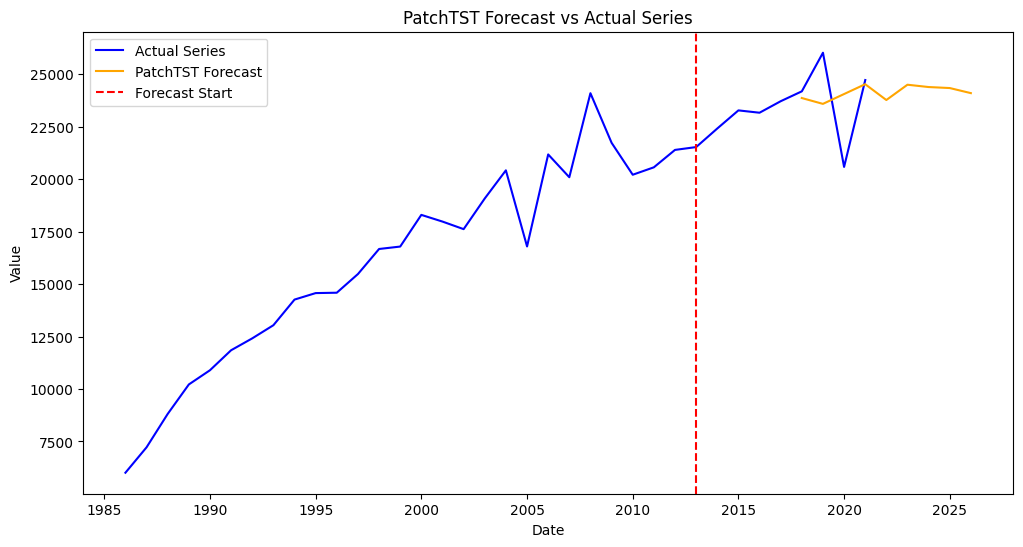

In [36]:
plot_ts_forecast(df_c, forecast_df, horizon)

In [37]:
forecast_df

,unique_id,ds,PatchTST
0,Aruba,2017-12-31,23867.951172
1,Aruba,2018-12-31,23589.302734
2,Aruba,2019-12-31,24056.845703
3,Aruba,2020-12-31,24526.664062
4,Aruba,2021-12-31,23773.117188
5,Aruba,2022-12-31,24502.150391
6,Aruba,2023-12-31,24391.892578
7,Aruba,2024-12-31,24343.384766
8,Aruba,2025-12-31,24101.054688


In [38]:
def process_country_forecasting(df_countries, country):
    """
    Function to process time series forecasting for a specific country.
    
    Parameters:
    - df_countries: DataFrame containing time series data for multiple countries
    - country: Name of the country to process
    - horizon: Number of years to forecast
    
    Returns:
    - forecast_df: DataFrame with forecasted values
    """
    df_c = add_till_2025(df_countries, country)
    df_c = df_c[~df_c["y"].isnull()]
    
    args = {
        "horizon": 6 + (2025 - int(df_c["Year"].max())),
        "input_size": 4,
        "max_steps": 150,
        "freq": 'Y',  # Annual frequency
        "patch_len": 16  # Length of the patch for PatchTST
    }
    
    _, forecast_df, metrics = neural_ts_forecasting(df_c, kwargs=args)
    
    return forecast_df

In [39]:
def update_main_df(df, forecast_df):
    """
    Function to update the main DataFrame with forecasted values.
    
    Parameters:
    - df: Main DataFrame containing time series data for multiple countries
    - forecast_df: DataFrame with forecasted values for a specific country
    
    Returns:
    - df: Updated DataFrame with forecasted values added
    """
    forecast_df["year"] = forecast_df["ds"].dt.year
    for yr in forecast_df["year"].unique().tolist():
        idx = df.index[(df["country"]==forecast_df["unique_id"].unique()[0])][0] # get the index of the country
        tmp_df = df[(df["country"]==forecast_df["unique_id"].unique()[0])]
        if tmp_df[str(yr)].isnull().values[0]: # fill in the nan values with the forecasted values
            df.at[idx, str(yr)] = forecast_df[forecast_df["year"]==yr]["PatchTST"].values[0]
    
    return df

In [40]:
from collections import defaultdict
steps = defaultdict(int)
for i, country in enumerate(df_countries[~df_countries["country"].isin(snag)]["country"].unique().tolist()):
    df_c = add_till_2025(df_countries, country)
    df_c = df_c[~df_c["y"].isnull()]
    horizon = (2025 - int(df_c["Year"].max()))
    # print(f"Number of steps to get till 2025 for {country}: {horizon}")
    steps[horizon] += 1
steps

defaultdict(int, {4: 205, 5: 8, 6: 1, 14: 1, 7: 2, 25: 2, 11: 1})

In [41]:
required_list_countries = df_countries[~df_countries["country"].isin(snag)]["country"].unique().tolist()
for i, country in enumerate(required_list_countries[:44]):
    if not np.array([x in df_countries[df_countries["country"]==country].columns for x in ["2022", "2023", "2024", "2025"]]).all():
        print(f"Country {country} does not have all required columns for 2022-2025.")
        continue

In [ ]:
required_list_countries = df_countries[~df_countries["country"].isin(snag)]["country"].unique().tolist()
for i, country in enumerate(required_list_countries[88:132]):
    print("*"*15+f"[{i+1}/44]"+"*"*15)
    print(f"Processing {country}")
    try:
        forecast_df = process_country_forecasting(df_countries, country)
        df_countries = update_main_df(df_countries, forecast_df)
    except Exception as e:
        print(f"Error processing {country}: {e}")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 400 K  | train
-----------------------------------------------------------
400 K     Trainable params
3         Non-trainable params
400 K     Total params
1.602     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


***************[1/44]***************
Processing IDA & IBRD total


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 400 K  | train
-----------------------------------------------------------
400 K     Trainable params
3         Non-trainable params
400 K     Total params
1.602     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


***************[7/44]***************
Processing Ireland


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
df_countries[["country", "2022", "2023", "2024", "2025"]].info()

In [ ]:
df_countries.to_csv("~/gcs-buckets/national_income_per_capita_forecasted.csv", index=False)